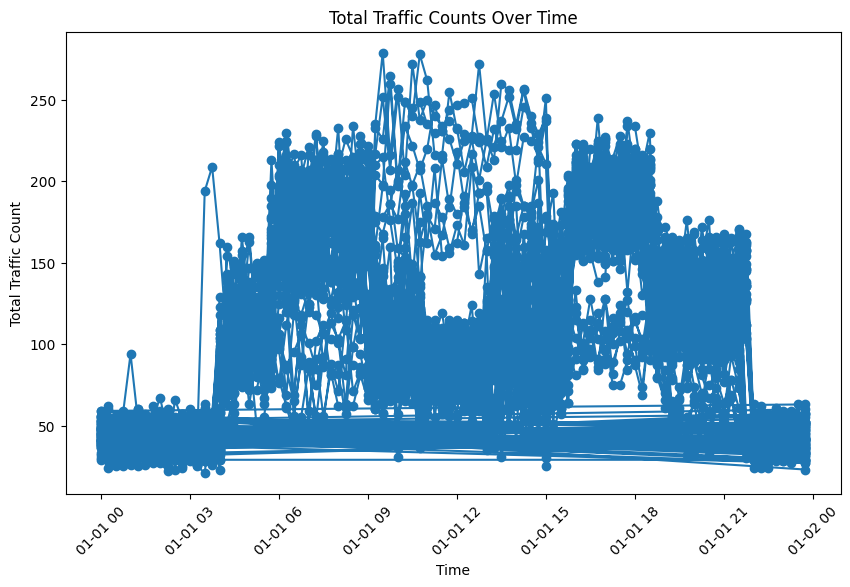

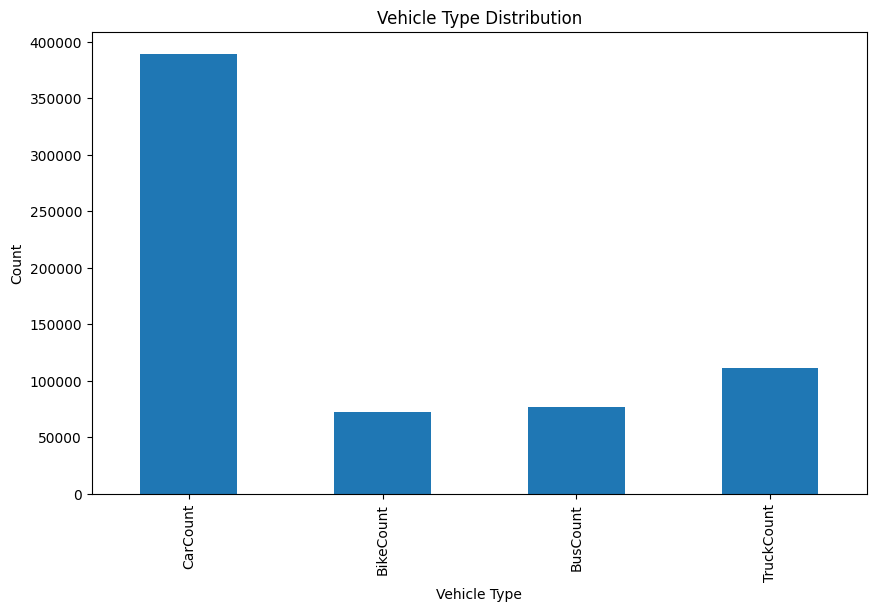

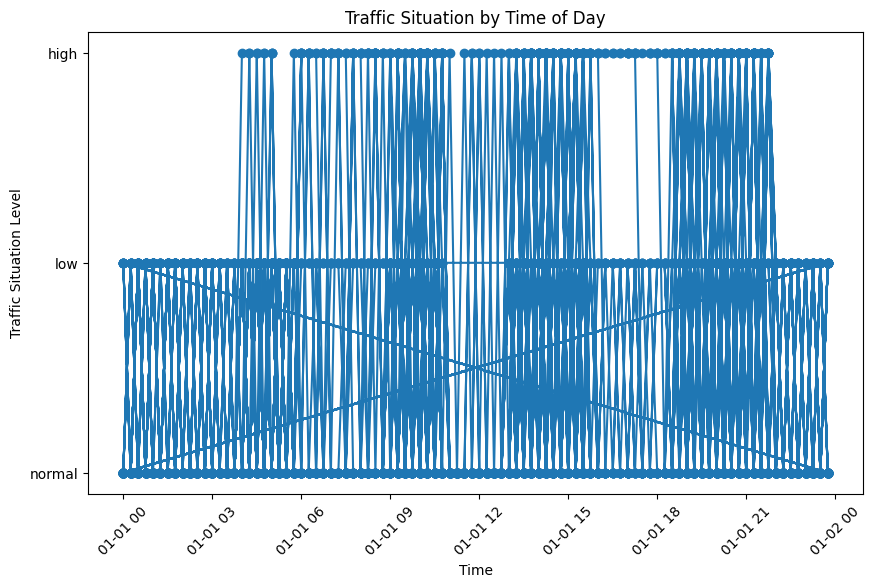

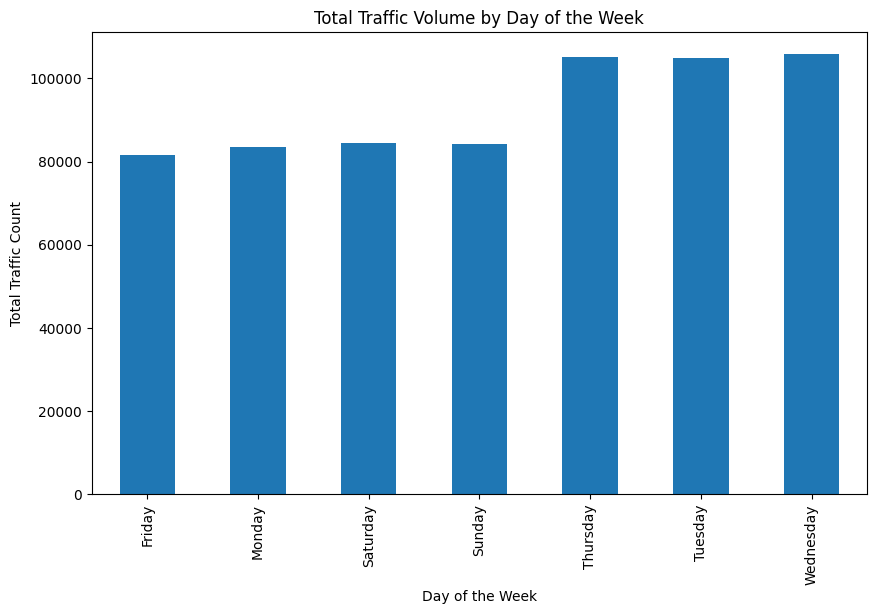

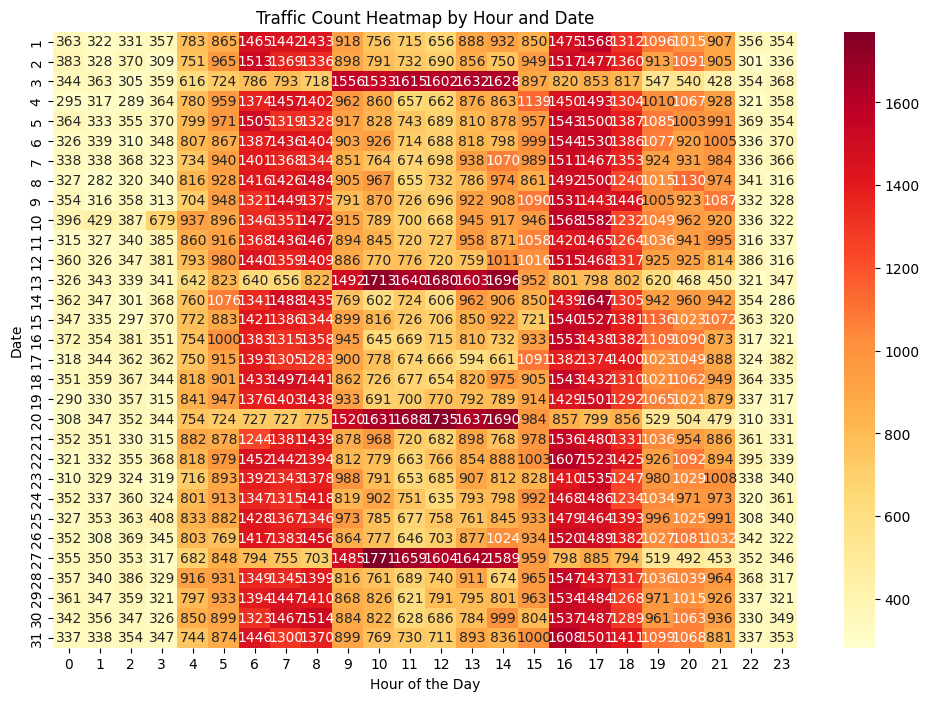

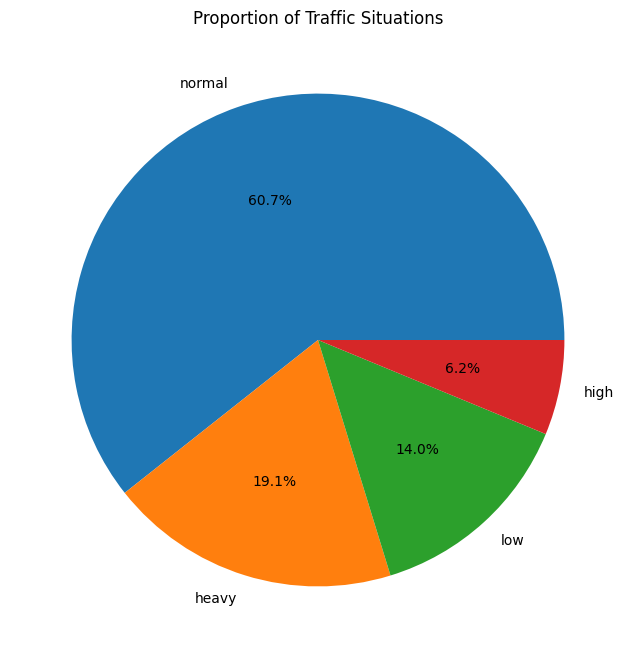

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset (adjust the path if necessary)
df = pd.read_csv('../Dataset/TrafficTwoMonth.csv')

# Convert Time to a datetime format (if required)
df['Time'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p')

# 1. Time Series of Total Traffic Counts
plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Total'], marker='o')
plt.title('Total Traffic Counts Over Time')
plt.xlabel('Time')
plt.ylabel('Total Traffic Count')
plt.xticks(rotation=45)
plt.show()

# 2. Vehicle Type Distribution
plt.figure(figsize=(10, 6))
vehicle_counts = df[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].sum()
vehicle_counts.plot(kind='bar')
plt.title('Vehicle Type Distribution')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.show()

# 3. Traffic Situation by Time of Day
plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Traffic Situation'].map({'normal': 1, 'low': 2, 'high': 3}), marker='o')
plt.title('Traffic Situation by Time of Day')
plt.xlabel('Time')
plt.ylabel('Traffic Situation Level')
plt.yticks([1, 2, 3], ['normal', 'low', 'high'])
plt.xticks(rotation=45)
plt.show()

# 4. Traffic Volume Comparison by Day of the Week
plt.figure(figsize=(10, 6))
df.groupby('Day of the week')['Total'].sum().plot(kind='bar')
plt.title('Total Traffic Volume by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Traffic Count')
plt.show()

# 5. Traffic Count Heatmap
import seaborn as sns
df['Hour'] = df['Time'].dt.hour
traffic_pivot = df.pivot_table(values='Total', index='Date', columns='Hour', aggfunc='sum')
plt.figure(figsize=(12, 8))
sns.heatmap(traffic_pivot, cmap='YlOrRd', annot=True, fmt=".0f")
plt.title('Traffic Count Heatmap by Hour and Date')
plt.xlabel('Hour of the Day')
plt.ylabel('Date')
plt.show()

# 6. Traffic Situation Proportion
plt.figure(figsize=(8, 8))
situation_counts = df['Traffic Situation'].value_counts()
situation_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Traffic Situations')
plt.ylabel('')
plt.show()
